In [2]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph ,START , END 
from typing import TypedDict , Literal
from pydantic import BaseModel , Field
from langchain_google_genai import ChatGoogleGenerativeAI
import json
load_dotenv()

True

In [3]:
class Review_Sentiment_Schema(BaseModel):

    Review_Sentiment : Literal['negetive','postive'] = Field(description='Figure out the sentiment of the review.')

In [4]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')


In [5]:
structured_model = model.with_structured_output(Review_Sentiment_Schema)


In [6]:
class Cons_parameters_Schema(BaseModel):

    emotion : Literal['angry','frustated','confused','sad'] = Field(description='Figure out the emtion of the review.')
    technical_issue:Literal['bug','logic_error','bad_ui','lag','poor_performance','support_issue']=Field(description="figure out the terchincal issue written in the review.")
    customer_type :Literal['old customer','new customer','not mentioned']=Field(description="Figure out if the customer is new or an old customer.")

In [7]:
structured_model_2 = model.with_structured_output(Cons_parameters_Schema)

In [8]:
class State_Schema(TypedDict):
    review : str
    sentiment : Literal['positive','negetive']
    response: str
    run_diagnosis : dict 
    



In [9]:
graph = StateGraph(State_Schema)

In [10]:
def sentiment(state:State_Schema):
    prompt = f"Find the sentiment of the {[state['review']]}"
    res = structured_model.invoke(prompt)

    return {'sentiment':res.Review_Sentiment}


In [11]:
def postive_response(state:State_Schema):
    prompt = f"Write a postive feedback to the customer for his this review to us and ask him to rate us out of 5: start directly with the response to the user :{[state['review']]}"
    res = model.invoke(prompt)

    return {'response':res.content}

In [12]:
def negetive_response(state:State_Schema):
    prompt = f"Write an apologizing feedback to the customer for his this review to us and keep the idea of the diagonised report {state['run_diagnosis']} and this is the review: start directly with the response to the user {[state['review']]}"
    res = model.invoke(prompt)

    return {'response':res.content}

In [13]:
def run_diagnosis(state:State_Schema):
    prompt = f"Analyze the review of the user and find the issues in it for three formats :   emotion,technical_issue,customer_type from this : {[state['review']]}"
    res = structured_model_2.invoke(prompt)

    return {'run_diagnosis':res.model_dump()}

In [14]:
def conditional_func(state:State_Schema)->Literal['postive_response','run_diagnosis']:
    if state['sentiment']=='negetive':
        return 'run_diagnosis'
    else:
        return 'postive_response'


In [15]:
#add nodes
graph.add_node('sentiment',sentiment)
graph.add_node('postive_response',postive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negetive_response',negetive_response)

# add edges 
graph.add_edge(START , 'sentiment')
graph.add_conditional_edges('sentiment',conditional_func)
graph.add_edge('run_diagnosis','negetive_response')
graph.add_edge('negetive_response',END)
graph.add_edge('postive_response',END)

workflow = graph.compile()




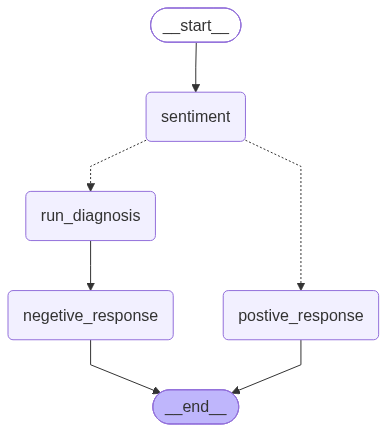

In [16]:
workflow

In [17]:
intial_state = {
    'review':"I bought this wireless headset last week, and it already stopped working. The sound cuts out randomly, and the battery drains way too fast. For the price I paid, this is unacceptable."
}

In [18]:
res = workflow.invoke(intial_state)


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [19]:
res

{'review': 'I bought this wireless headset last week, and it already stopped working. The sound cuts out randomly, and the battery drains way too fast. For the price I paid, this is unacceptable.',
 'sentiment': 'negetive',
 'response': "We are truly sorry to hear about the incredibly frustrating experience you've had with your new wireless headset. It's completely unacceptable that it stopped working so soon after purchase, with the sound cutting out and the battery draining rapidly.\n\nWe understand your anger, especially as a new customer whose first experience with us has been one of poor performance. This is definitely not the quality we strive for, nor the reliable experience we want for any of our customers.\n\nWe want to make this right immediately. Please contact our customer support team directly at [Your Phone Number] or [Your Email Address] so we can promptly arrange a replacement for you. We are committed to ensuring you receive a fully functional headset that meets your e